# Spatial | Allocentric Head Direction
-----------------------------------------

## Setup and Configuration

In [1]:
##### Imports ##########################################################################

#==== Generic Imports ================
from pathlib import Path
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display


#==== Movement Imports ===============
import movement.kinematics
import movement.utils.vector

#==== DataConduit Imports (Core) =====
import data_conduit as dc
from data_conduit.datastructures import slice_stream, slice_stream_per_trial
from data_conduit.integrations.DLC.pose import pose_to_movement                           # Import used for combining DLC pose & confidence streams into a single object
#       matches `movement`'s own conventions

#==== DataConduit Imports (Unique) ===
from movement_figures.data_template.loading import build_datastructure

from movement_figures.misc import visual_streams_check, configure_simplified_trial_df
from movement_figures.timeseries_template.annotations import annotate_qc_timeseries

from data_conduit.refactor_qc import (                                          # Imports for trial filtering based on experiment protocol
    TRAINING_FIRST_MID_LAST_DETAIL,
    training_spec,
    training_session_names,
    filter_trials,
)
from movement_figures.timeseries_template.annotations import AnnotationResult


### Notebook Settings ######################################################

pd.set_option("display.max_columns", None)                                      # Changes default pandas display settings to show all columns in a dataframe.
pd.set_option("display.max_rows", None)                                         # Changes default pandas display settings to show all rows in a dataframe.

In [2]:
##### Setup Parameters #################################################################

# === 1| Select Mice, Days and Recording Folders Before Reading Files =============
ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")

LEVEL_SELECTORS = {
    'l0_selector': 'MR_M01569515', 
    'l1_selector': 'Day21'
    }                                                                                       # Example choices belong here: l0_selector and l1_selector.
# INCLUDE_SESSIONS = ('2026-06-21T093349Z',)                                                # Optional list of recording folder names; None keeps selected folders.
# STREAMS = ('trials', 'events', 'video', 'dlc')                                            # These figures require events/trials and aligned pose; other sources remain available.


#=== 2| Set the trial filtering parameters for the experiment protocol ============
spec = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)                                        # Flattens `{training_detail}` table into per-session spec. 

# included_sessions = training_session_names(spec)                                          # Returns a list of session folder names that match the spec.
#   Not used here, as sessions have been filtered in another way. If other sessions 
#   not in the above spec are used, then applying the `filter_trials` function with 
#   the above spec could result in incorrect filtering.


In [3]:
##### Load DataStructure ###############################################################

#=== Load data ========================================================================

fig_ds_obj = build_datastructure(
    root               = ROOT,                                                                 # Directory above the named hierarchy levels.
    level_names        = ("mouseID", "day"),                                                   # Lab layout: root / mouseID / day / session.
    streams            = ("trials", "session_settings", "video", "dlc"),                       # Data streams to be included in the datastructure.
    include            = None,                                                                 # Keep these session folder names; None keeps all.
    exclude            = None,                                                                 # Alternatively omit these session folder names.
    raw_events         = True,                                                                 # Convenience alias for adding "events" to the requested sources.
    device_yaml        = "./device.yml",                                                       # Lab Nosepoke board register definitions.
    soundcard_yaml     = "./soundcard.yml",                                                    # Lab SoundCard register definitions.
    nosepoke_count     = 18,                                                                   # Port count used by the existing Q_C parser.
    trial_start_buffer = 0.0,                                                                  # Preserve the existing lab parser setting.
    dlc_file_format     = "auto",                                                              # Existing reader prefers CSV, otherwise HDF5.
    trial_spec = None,                                                                         # Optional experiment rules; None keeps the existing Q_C specification. 
    #    Not used here, as sessions are already selected. 
    #    If session is not one in the spec, then subsequent use of 
    #   `filter_trials` to apply correct experiment protocol rules could be incorrect.
    
    **LEVEL_SELECTORS,
)


#=== Select and load the streams of interest from datastructure. ======================
fig_ds_obj.select()
streams = fig_ds_obj.load()                                                                    # Load is required to access the selected streams.

#=== Create convenient compact trial dataframe without some unnecessary columns. ======
streams['compact_trials'] = configure_simplified_trial_df(              
    trial_df = streams['trials'],
    modify_in_place = False,                                                                   # Whether to modify the trial dataframe in place or return a new dataframe. 
)
'''More useful for visual inspection and analysis. 
Check the misc.py file for the default columns to keep and drop.'''


#=== Apply Trial Filtering Protocol to construct new stream objects ===================

# Full filtered trials
streams['filtered_trials'] = filter_trials(
    trials = streams['trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

# Filtered compact trials 
streams['filtered_compact_trials'] = filter_trials(
    trials = streams['compact_trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

#=== Merge Pose & Confidence Streams ==================================================
streams['dlc:movement'] = pose_to_movement(
    slice_stream(streams["dlc:position"],   
                #selectors={"session": session_id}
    ),
    slice_stream(streams["dlc:confidence"], 
                 #selectors={"session": session_id}
    ),
)

#=== Visual streams check =============================================================
visual_streams_check(
    loaded_ds_object = streams,                                                                # Loaded dataset object containing all streams of interest.
    show_stream_shapes = True,                                                                 # Whether to display the shapes of the streams.
    show_stream_dtypes = True,                                                                 # Whether to display the data types of the streams.
    display_streams = False                                                                    # Whether to display the actual stream data as a table.
)



     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80
     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80


=========================
### Summary of Loaded Streams
=========================

,Stream Name,Shape,Type
0,session_settings:metadata,"(1, 23)",DataFrame
1,session_settings:trials,"(303, 132)",DataFrame
2,video,"(36354, 5)",DataFrame
3,dlc:position,"(36354, 5, 2)",DataArray
4,dlc:confidence,"(36354, 5)",DataArray
5,events,"(1487, 5)",DataFrame
6,trials,"(106, 28)",DataFrame
7,compact_trials,"(106, 19)",DataFrame
8,filtered_trials,"(80, 30)",DataFrame
9,filtered_compact_trials,"(80, 21)",DataFrame


## Select Trials to Show

In [4]:
##### Trial Selection ##################################################################

#==== Extract Trial Range ============
selected_trials = slice_stream(streams['filtered_trials'][:20])              # Select the first n trials

#==== Extract Recording Identifier ===
sessionID = selected_trials['session'].unique().item()                      # Extract unique sID from selected trials, remove duplicates, ensure single value.

#==== Select Tracked Positions =======
recording = slice_stream(stream = streams['dlc:movement'],                  # selectors{} here keeps movement data belonging to the specified session only.
                        selectors = {'session' : sessionID }, 
)

position = recording['position']                                            # ['position'] extracts positional data from the movement stream.

position = position.sel(individual='individual_0',                          # .sel() selects the specified individual from the positional data.
                        drop=True,                                          # drop=True removes the individual dimension from the resulting DataArray, but leaves other dims intact.
)



## Compute Allocentric Head Direction

In [5]:
##### Compute Allocentric Head Direction Using `movement` ##############################

#==== Calculate HD Angle =============
allocentric_hd = movement.kinematics.compute_forward_vector_angle(
    data             = position,
    left_keypoint    = 'lear',
    right_keypoint   = 'rear',
    reference_vector = (0, -1),                                     # Points to top edge of frame on y-axis
    camera_view      = 'top_down',
    in_degrees       = False,                                    # Keep radians; the plot converts to display units.
)
allocentric_hd.name = "allocentric_head_direction"
allocentric_hd.attrs["units"] = "rad"
#==== Slice to Selected Range ========

selected_allocentric_hd = slice_stream_per_trial(
    stream     = allocentric_hd,
    trials     = selected_trials,
    segment    = 'trial',
    time_coord = 'time'
)

selected_allocentric_hd = xr.concat(selected_allocentric_hd,
                                    dim= 'time',
)

## Head Direction Plotting Function

In [6]:
def add_annotations(ax, 
                    selected_trials,
                    **kwargs
                    ):
    '''
    Add annotations to the given axis using the selected trials.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis to which annotations will be added.
    selected_trials : pd.DataFrame
        The selected trials used for annotations.

    Returns
    -------
    matplotlib.axes.Axes
        The axis with annotations added.
    '''
    return annotate_qc_timeseries(ax=ax, trials=selected_trials, **kwargs)

In [7]:
##### Plot Head Direction on Ax ########################################################

def plot_ax_allocentric_head_direction(
    ax: plt.Axes,
    head_direction: xr.DataArray,
    selected_trials: pd.DataFrame,
    units: str = 'Degrees',
    row_duration: float | None = 60.0,
    subtitle: str | None = 'Allocentric Head Direction',
    add_annotations_func: Callable[..., AnnotationResult] | None = add_annotations,
    annotation_kwargs: dict | None = None,
    **kwargs,
) -> plt.Axes:
    '''
    Plot Allocentric Head Direction angles onto consecutive time rows.

    Parameters
    ----------
    ax : plt.Axes
        The matplotlib Axes object to plot on.
    head_direction : xr.DataArray
        The head direction data in radians as an xarray DataArray.
    selected_trials : pd.DataFrame
        DataFrame containing the trials to be plotted.
    units : str, optional
        Units for the head direction angles. Default is 'Degrees'.
    row_duration : float or None, optional
        Duration of each row in seconds. Default is 60.0.
    subtitle : str or None, optional
        Subtitle for the plot. Default is 'Allocentric Head Direction'.
    add_annotations_func : Callable[..., AnnotationResult] or None, optional
        Function to add annotations to the plot. Default is add_annotations.
    annotation_kwargs : dict or None, optional
        Additional keyword arguments for the annotation function. Default is None.
        The callback receives the axis and selected_trials positionally.
    **kwargs
        Additional keyword arguments passed to the plotting function.

    Returns
    -------
    ax : plt.Axes
        The matplotlib Axes object with the plotted head direction.
        Original axis; multiple rows are available through ax.child_axes.
    '''

    #==== 0| Validation Checks =======================================
    if ax is None:
        raise ValueError("ax must be provided")
    if head_direction is None:
        raise ValueError("head_direction must be provided")



    #==== 1| Calculate Rows Needed for Subplot =======================
    range_start = float(head_direction['time'][0])
    range_end   = float(head_direction['time'][-1])

    duration = range_end - range_start if row_duration is None else row_duration
    row_count = max(1, int(np.ceil((range_end - range_start) / duration)))


    #==== 2| Create the Required Time Rows ===========================
    if row_count == 1:
        row_axes = [ax]

    else:
        ax.set_axis_off()                                                           # Use the supplied axis as the container for the rows.

        row_axes = []                                                               # List to hold the axes for each row
        row_height = 1 / (row_count + 0.25 * (row_count - 1))                       # Calculate the height of each row considering the gaps between them.
        row_gap = 0.25 * row_height                                                 # Calculate the gap between rows as a fraction of the row height.

        for row in range(row_count):                                                # Create an inset axis for each row
            bottom = 1 - (row + 1) * row_height - row * row_gap                     # Calculate the bottom position of the current row.
            row_axes.append(                                                        # Append the inset axis for the current row to the list of row axes.
                ax.inset_axes([0, bottom, 1, row_height])
            )


    #==== 3| Convert Units if Necessary ==============================
    if units == "Degrees":
        adjusted_head_direction = np.rad2deg(head_direction)
        limit = 180.0
        ticks = [-180, -90, 0, 90, 180]
        tick_labels = ["-180", "-90", "0", "90", "180"]
    
    elif units == "Radians":
        adjusted_head_direction = head_direction
        limit = np.pi
        ticks = [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]
        tick_labels = [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"]
    
    else:
        raise ValueError("units must be 'Degrees' or 'Radians'.")


    #==== 4| Set Plotting Parameters =================================
    #       left blank for now intentionally.


    #==== 5| Plot Allocentric HD and Matching Annotations ============
    annotation_kwargs = annotation_kwargs or {}

    for row, row_ax in enumerate(row_axes):

        row_start = range_start + row * duration                                    # Calculate start time of current row
        row_end = min(row_start + duration, range_end)                              # Calculate end time of current row, ensure it does not exceed  overall range.

        row_allo_hd = adjusted_head_direction.sel(time=slice(row_start, row_end))

        row_ax.plot(row_allo_hd.time,                                               # Plot the allocentric head direction for the current row
                    row_allo_hd,
                    '.',
                    **kwargs
        )

        row_ax.set(xlim=(row_start, row_start + duration), ylim=(-limit, limit),    # Set the x and y axis limits for the current row
                   xlabel="Time (Seconds)", ylabel=f"Head Direction ({units})")
        row_ax.set_yticks(ticks, labels=tick_labels)                                # Set the y-axis ticks and labels for the current row

        row_ax.axhline(0, linewidth=0.8)                                            # Add a horizontal line at y=0 for reference
       
        # Keep annotation coordinates in the original recording-time units.
        if add_annotations_func is not None:
            if selected_trials is None:
                raise ValueError("selected_trials must be provided")

            add_annotations_func(
                row_ax,
                selected_trials,
                **(annotation_kwargs or {}),
            )

    
    #==== 6| Add the Plot Title ======================================
    if subtitle is not None:
        row_axes[0].set_title(subtitle)
    return ax








## Generate Plot

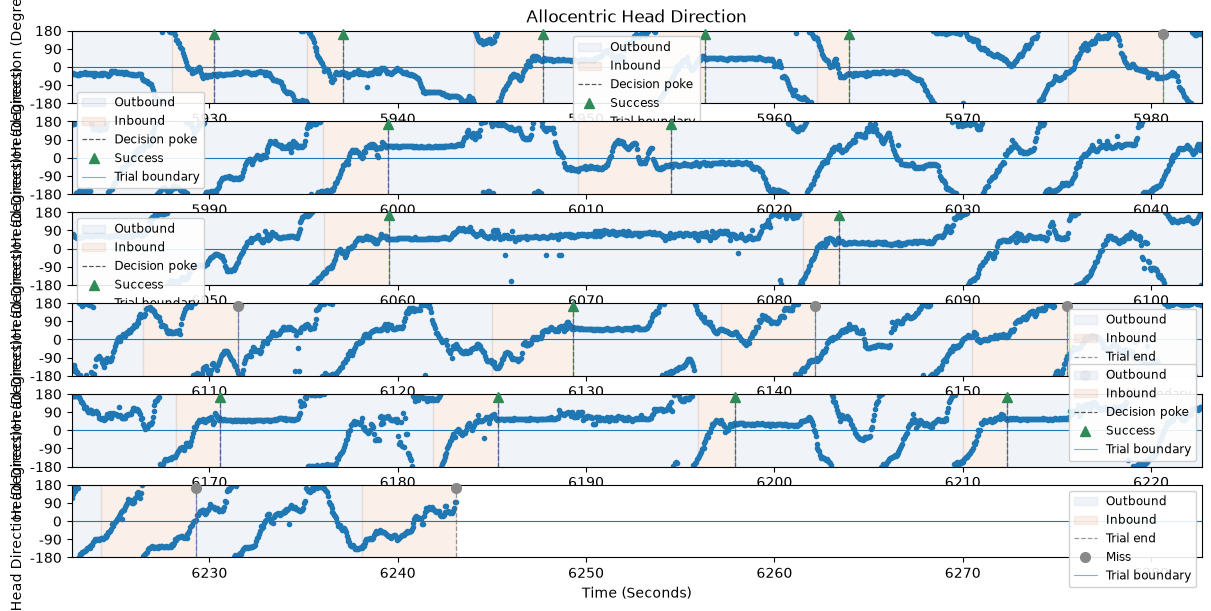

In [9]:
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

ax = plot_ax_allocentric_head_direction(
    ax = ax,
    head_direction = selected_allocentric_hd,
    selected_trials = selected_trials,
    units = 'Degrees',
    row_duration = 60.0,
    subtitle = 'Allocentric Head Direction',
    add_annotations_func = add_annotations,
    annotation_kwargs = None,
)
